# Data Exploration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/kaggle/input/datasets/karkavelrajaj/amazon-sales-dataset/amazon.csv')

In [3]:
df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  review_content       1465 non-null   object
 14  img_link             1465 non-null   object
 15  product_link         1465 non-null   object
dtypes: obj

# Data Transformation

In [5]:
#1
df['discounted_price'] = df['discounted_price'].str.replace('₹', '').str.replace(',', '').astype(float)
df['actual_price'] = df['actual_price'].str.replace('₹', '').str.replace(',', '').astype(float)
df['discount_percentage'] = df['discount_percentage'].str.replace('%', '').astype(float)

In [6]:
#2
df['rating_count'] = df['rating_count'].str.replace(',', '').fillna('0').astype(int)
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

In [7]:
#3
df['rating'] = df['rating'].fillna(df['rating'].median())

In [8]:
#4
df['main_category'] = df['category'].astype(str).str.split('|').str[0]
df['discount_amount'] = df['actual_price'] - df['discounted_price']

In [9]:
#5
df[['discounted_price', 'actual_price', 'discount_percentage', 'rating', 'rating_count']].dtypes

discounted_price       float64
actual_price           float64
discount_percentage    float64
rating                 float64
rating_count             int64
dtype: object

# Data Analysis

In [10]:
category_summary = df.groupby('main_category').agg(
    total_products=('product_id', 'count'),
    avg_rating=('rating', 'mean'),
    avg_discount=('discount_percentage', 'mean'),
    avg_discount_price=('discounted_price', 'mean')
).reset_index()

category_summary.sort_values(by='total_products', ascending=False)

,main_category,total_products,avg_rating,avg_discount,avg_discount_price
2,Electronics,526,4.081749,50.828897,5965.887833
1,Computers&Accessories,453,4.154967,54.024283,842.650375
4,Home&Kitchen,448,4.040848,40.120536,2330.615647
7,OfficeProducts,31,4.309677,12.354839,301.580645
6,MusicalInstruments,2,3.900000,46.000000,638.000000
5,HomeImprovement,2,4.250000,57.500000,337.000000
0,Car&Motorbike,1,3.800000,42.000000,2339.000000
3,Health&PersonalCare,1,4.000000,53.000000,899.000000
8,Toys&Games,1,4.300000,0.000000,150.000000


In [11]:
correlation_matrix = df[['actual_price', 'discounted_price', 'discount_percentage', 'rating', 'rating_count']].corr()
correlation_matrix

,actual_price,discounted_price,discount_percentage,rating,rating_count
actual_price,1.000000,0.961915,-0.118098,0.121636,-0.035890
discounted_price,0.961915,1.000000,-0.242412,0.120335,-0.027010
discount_percentage,-0.118098,-0.242412,1.000000,-0.155273,0.010868
rating,0.121636,0.120335,-0.155273,1.000000,0.101575
rating_count,-0.035890,-0.027010,0.010868,0.101575,1.000000


# Data Vizualization

**A. Distribution of Products Across Categories**

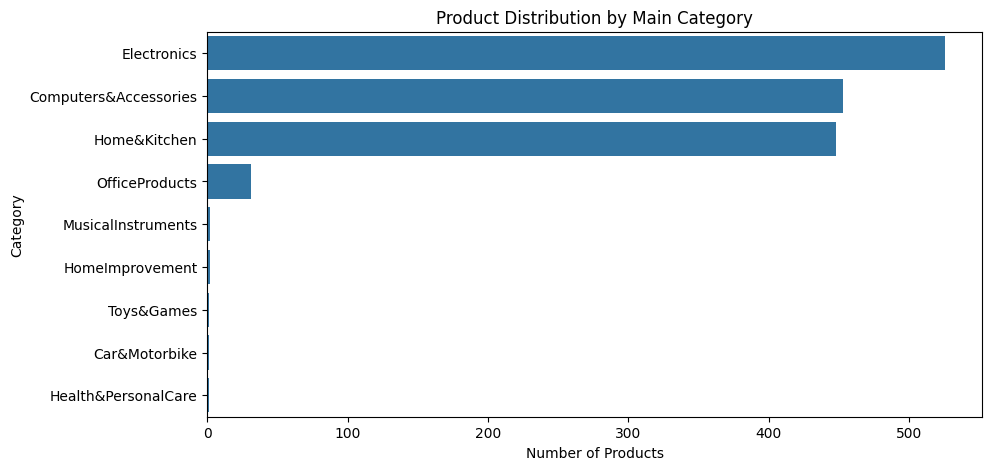

In [12]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, y='main_category', order=df['main_category'].value_counts().index)
plt.title('Product Distribution by Main Category')
plt.xlabel('Number of Products')
plt.ylabel('Category')
plt.show()

Conclusion A:

The product catalog is dominated by **Electronics, Computers & Accessories, and Home & Kitchen**, while all other categories contain significantly fewer products. This shows a strong focus on technology and household products.

# B. Correlation Heatmap

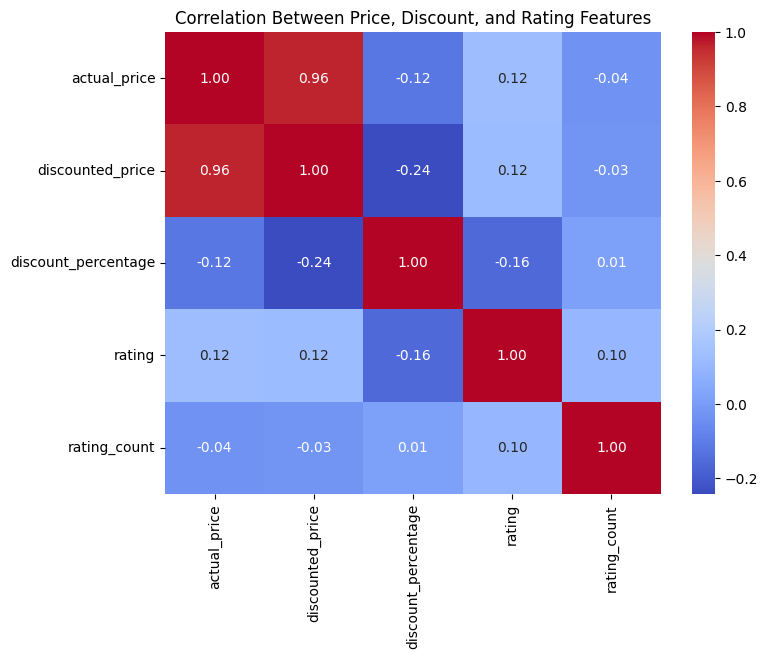

In [13]:
plt.figure(figsize=(8,6))

correlation_matrix = df[['actual_price',
                         'discounted_price',
                         'discount_percentage',
                         'rating',
                         'rating_count']].corr()

sns.heatmap(correlation_matrix,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title('Correlation Between Price, Discount, and Rating Features')
plt.show()

Conclusion B: 

There is a very strong positive correlation between actual price and discounted price **(0.96)**, indicating that higher-priced products tend to remain more expensive even after discounts. The discount percentage shows a weak negative relationship with both prices and ratings, suggesting that larger discounts are not strongly associated with higher ratings or product popularity. Overall, product ratings and rating counts have only weak correlations with price and discount features, indicating that customer feedback is relatively independent of pricing.

# C. Discount Percentage vs. Rating

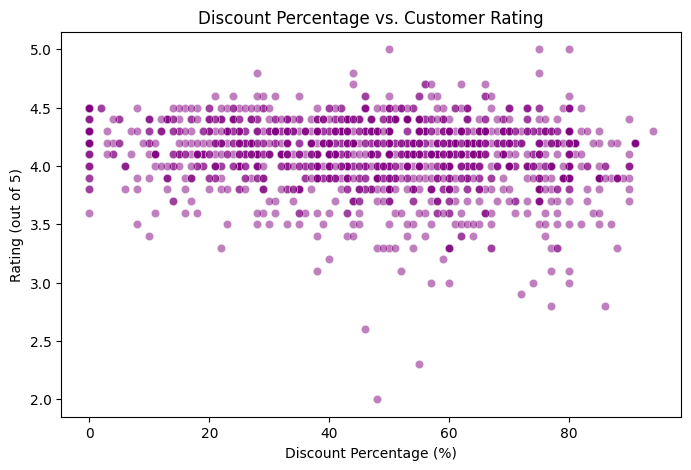

In [14]:
#scatterplot vizualization:

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data = df,
    x = 'discount_percentage',
    y = 'rating',
    alpha = 0.5,
    color = "purple"
)

plt.title('Discount Percentage vs. Customer Rating')
plt.xlabel('Discount Percentage (%)')
plt.ylabel('Rating (out of 5)')
plt.show()

Conclusion C:

The scatter plot shows no strong relationship between discount percentage and customer rating. Most products maintain ratings between 3.5 and 4.5 regardless of the discount offered. This suggests that larger discounts do not necessarily lead to higher customer ratings, and product ratings are relatively independent of discount levels.

# D. Top 10 Most Reviewed Products

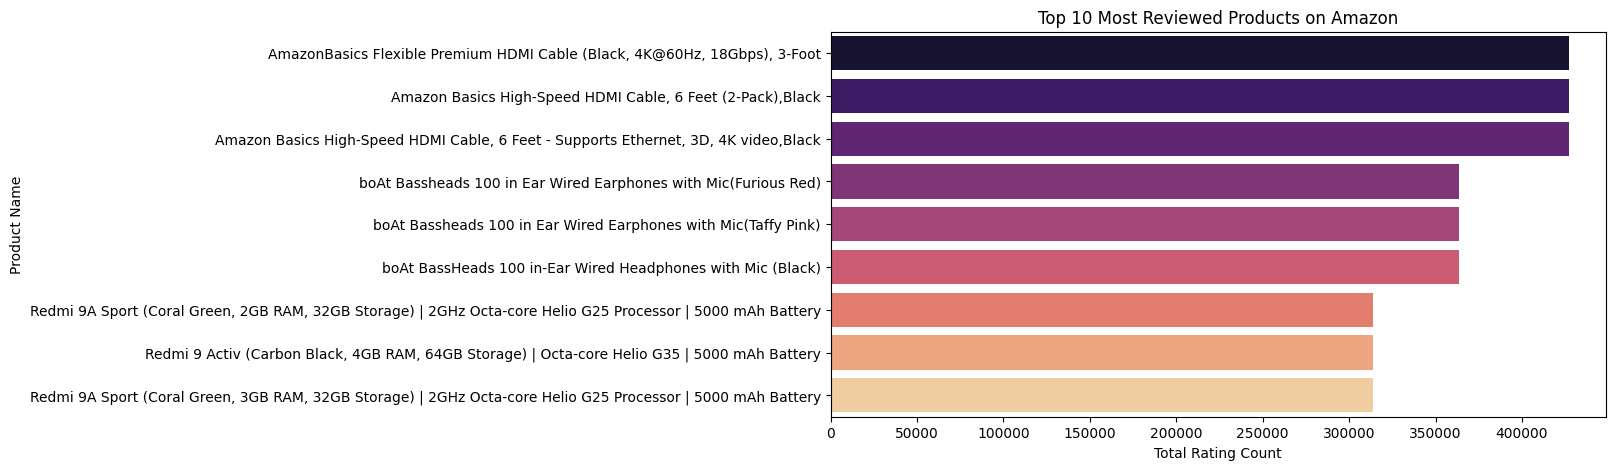

In [15]:
top_reviewed = df.sort_values(by='rating_count', ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(
    data=top_reviewed,
    x='rating_count',
    y='product_name',
    hue='product_name',
    palette='magma',
    legend=False
)

plt.title('Top 10 Most Reviewed Products on Amazon')
plt.xlabel('Total Rating Count')
plt.ylabel('Product Name')
plt.show()

Conclusion D:

Amazon's most reviewed products are dominated by Amazon Basics HDMI cables and boAt Bassheads earphones, with review counts exceeding **350,000–420,000**. These products significantly outperform others in customer engagement, while Redmi smartphones also rank among the top-reviewed items, indicating strong popularity in the electronics category. Overall, affordable electronics and accessories attract the highest number of customer reviews.

# E. Distribution of Product Ratings

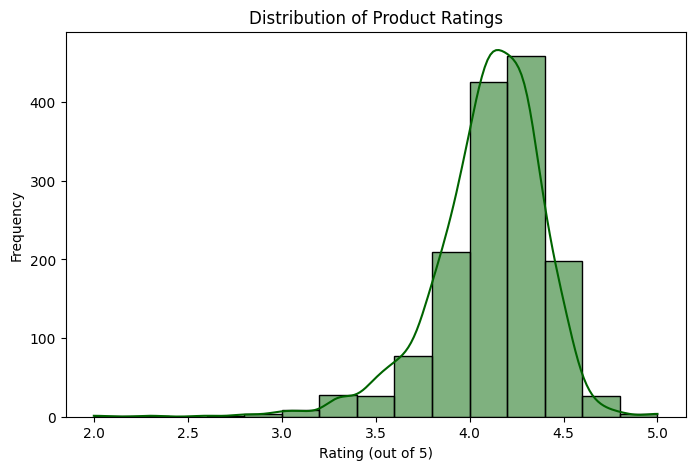

In [16]:
#histogram

plt.figure(figsize=(8,5))
sns.histplot(df['rating'], bins=15, kde=True, color='darkgreen')
plt.title('Distribution of Product Ratings')
plt.xlabel('Rating (out of 5)')
plt.ylabel('Frequency')
plt.show()

Conclusion E:

The distribution of product ratings is heavily concentrated between **4.0** and **4.5**, with a peak around **4.2–4.3.** Very few products have ratings below 3.5 or above 4.8, indicating that most products receive consistently positive customer feedback. Overall, the dataset is dominated by highly rated products, suggesting strong customer satisfaction.

# F. Multi-Variable Box Plot: Price Distribution Across Top Categories

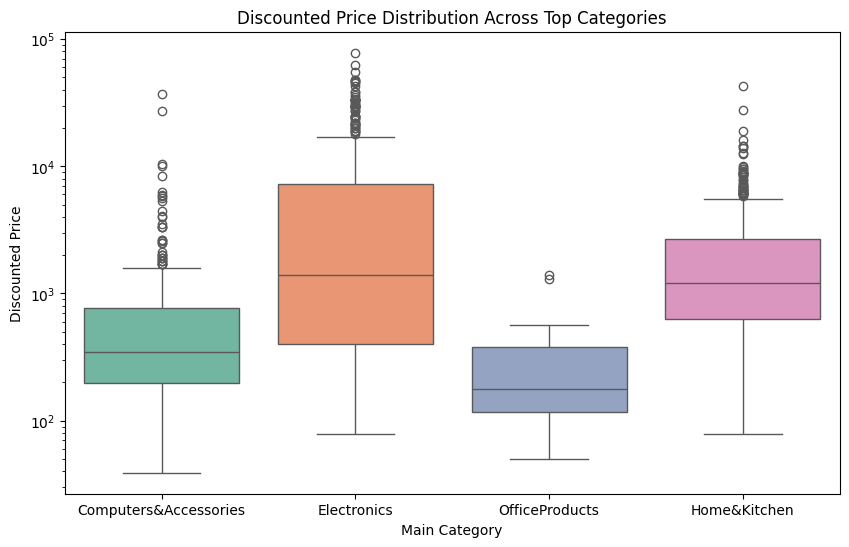

In [17]:
top_categories = df['main_category'].value_counts().nlargest(4).index
df_filtered = df[df['main_category'].isin(top_categories)]

plt.figure(figsize=(10, 6))
sns.boxplot(
    data = df_filtered,
    x = 'main_category',
    y = 'discounted_price',
    hue = 'main_category',
    palette = 'Set2',
    legend = False
)

plt.yscale('log')
plt.title('Discounted Price Distribution Across Top Categories')
plt.xlabel('Main Category')
plt.ylabel('Discounted Price')
plt.show()

Conclusion F:

Electronics and Home & Kitchen products have the **highest** median discounted prices and the **widest** price ranges, indicating greater variation in product offerings. Office Products are generally the **most affordable** category, while Computers & Accessories fall in the **mid-price** range. The presence of numerous outliers across categories suggests that a small number of premium products are available at significantly higher prices than the majority of items.

# Overall Project Summary

This analysis focused on exploring an Amazon product dataset to understand product distribution, pricing, discounts, ratings, and customer engagement. The goal was to identify key patterns and relationships that could provide insights into product popularity and customer behavior.
Approach
The analysis was conducted through several stages:


# Data Exploration and Preparation

Examined the dataset structure and key variables.
Identified important features such as product category, actual price, discounted price, discount percentage, rating, and rating count.
Cleaned and prepared the data for analysis and visualization.


# Category Analysis

Analyzed the distribution of products across categories.
Found that Electronics, Computers & Accessories, and Home & Kitchen dominate the catalog, indicating that the platform is heavily focused on technology and household products.



# Price and Discount Analysis

Compared actual and discounted prices across major categories.
Identified significant price variations, especially within the Electronics and Home & Kitchen categories.
Observed that categories contained both budget-friendly and premium products.



Customer Rating Analysis

Examined the distribution of product ratings.
Found that most products were rated between 4.0 and 4.5, suggesting generally high customer satisfaction.



# Relationship Analysis

Used correlation analysis and scatter plots to investigate relationships between price, discounts, and ratings.
Discovered a very strong relationship between actual and discounted prices, while discount levels showed little influence on customer ratings.



# Customer Engagement Analysis

Identified the top reviewed products.
Found that Amazon Basics accessories and boAt earphones generated the highest review counts, indicating strong customer engagement and popularity.



# Key Achievements

Identified the dominant product categories in the dataset.
Evaluated pricing and discount patterns across categories.
Measured customer satisfaction through rating distributions.
Determined that higher discounts do not necessarily result in higher ratings.
Revealed the products receiving the highest levels of customer interaction.
Generated clear visualizations that made trends and relationships easier to interpret.

# Final Conclusion

The analysis shows that Amazon's marketplace is strongly centered around electronics and household products, with most products receiving high customer ratings. While pricing and discount strategies vary significantly across categories, customer ratings remain relatively stable and are only weakly influenced by discounts. Overall, the dataset suggests a marketplace where product quality and customer satisfaction are consistently high, and where popular electronics and accessories drive the majority of customer engagement.